In [1]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_generator import *
from inference import *
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random
%matplotlib inline
plt.ion()  

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
# config 
VISION_RADIUS = float('inf')
LOS = 'los4'
GRAZING = True

Generated Grid:


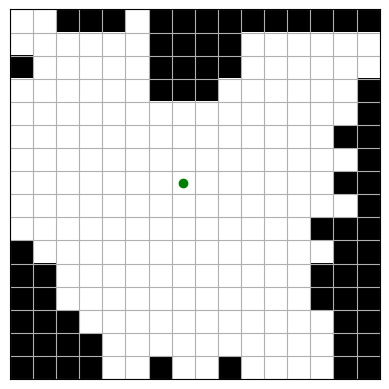

In [4]:
# Generate a random grid
gen = WRPDataGenerator(16, 16)
grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


Optimized Path Length: 42


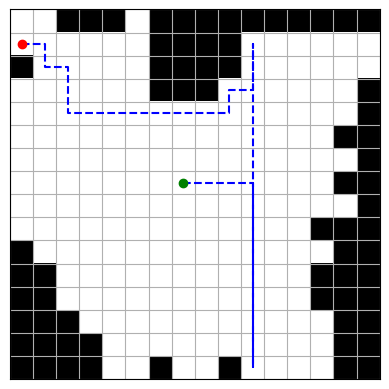

In [5]:
solver_opt = WRPSolverTSPJF(grid, start, los_type=LOS,  vision_radius=VISION_RADIUS)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)

print("Optimized Path Length:", len(path_opt))

plot_path(grid, path_opt, start)

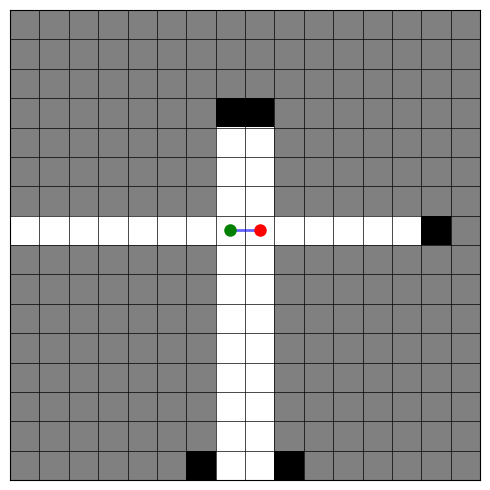

<Axes: >

In [9]:
plot_visibility2(grid, path_opt[:2], los_type=LOS, vision_radius=VISION_RADIUS, grazing_walls=GRAZING)

In [ ]:
X1, y1 = generate_training_data_for_online_learning(grid, path_opt, grazing_walls = GRAZING, discounted_step=10, los_type=LOS, vision_radius=VISION_RADIUS)

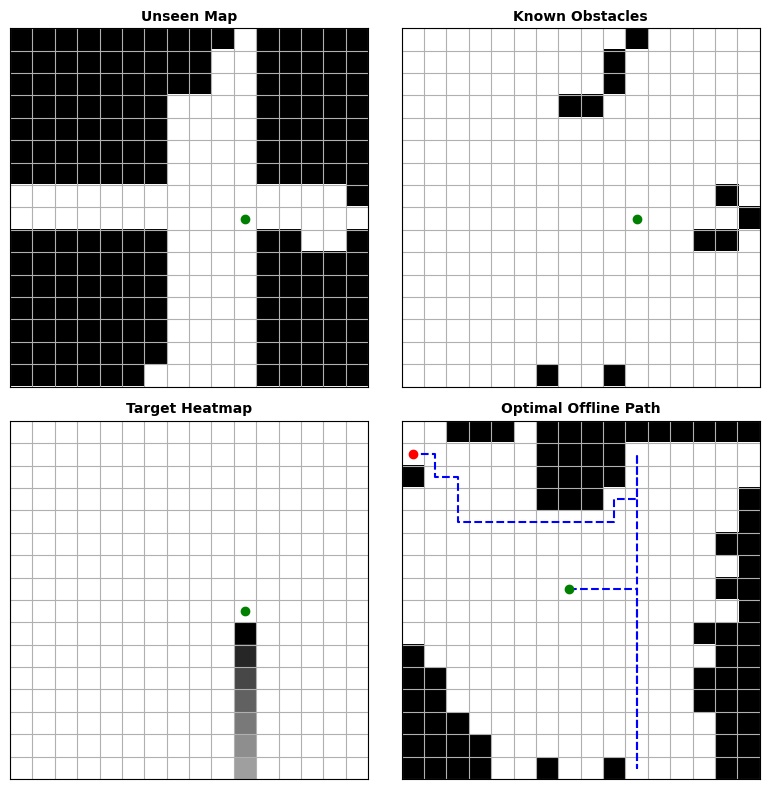

In [13]:
step = 4
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
ax = axes.ravel()

curr_loc_idx = X1[step][1].argmax(axis=None)
curr_loc = np.unravel_index(curr_loc_idx, X1[step][1].shape)

plt.sca(ax[0])
plot_grid(X1[step][2], curr_loc)
ax[0].set_title("Unseen Map", fontsize=10, fontweight="bold")

plt.sca(ax[1])
plot_grid(X1[step][0], curr_loc)
ax[1].set_title("Known Obstacles", fontsize=10, fontweight="bold")



plt.sca(ax[2])
plot_grid(y1[step][0], curr_loc)
ax[2].set_title("Target Heatmap", fontsize=10, fontweight="bold")


plt.sca(ax[3])
plot_path(grid, path_opt, start)
ax[3].set_title("Optimal Offline Path", fontsize=10, fontweight="bold")


plt.tight_layout()
plt.show()

In [ ]:
#filter out data from X_train when unseen cell are less than half of the total cells in the grid   

def filter_samples_from_data(X_train, y_train, no_filtering=True):
    if no_filtering:
        return X_train, y_train  # Return original data without filtering
    filtered_X = []
    filtered_y = []
    
    for i in range(len(X_train)):
        unseen_map = X_train[i][2]  # Assuming the unseen map is at index 2
        H, W = unseen_map.shape[-2], unseen_map.shape[-1]
        total_cells = H * W
        unseen_cells = unseen_map.sum().item()  # Count of unseen cells (assuming unseen cells are marked with 1)
        
        if unseen_cells <= total_cells / 1.5:  # Keep samples where unseen cells are less than or equal to two-thirds of total cells
            filtered_X.append(X_train[i])
            filtered_y.append(y_train[i])
    
    return torch.stack(filtered_X), torch.stack(filtered_y)


In [122]:
# if LOS == 'los4':
#     X_train1, y_train1 = load_data_from_disk("data/wrp_online_grazing_data_16x16_1000_samples_SP_train.pt")
#     X_train2, y_train2 = load_data_from_disk("data/wrp_online_grazing_data_16x16_1000_samples_SP_train2.pt")
#     X_train3, y_train3 = load_data_from_disk("data/wrp_online_grazing_data_16x16_1000_samples_SP_train3.pt")

#     X_train_hard, y_train_hard=load_data_from_disk("data/wrp_online_grazing_data_16x16_780_samples_SP_train_hard.pt", sample = 0.5)

#     X_test, y_test = load_data_from_disk("data/wrp_online_grazing_data_16x16_750_samples_SP_test.pt")
    
#     X_train, y_train = torch.cat([X_train1, X_train_hard, X_train2, X_train3]), torch.cat([y_train1, y_train_hard, y_train2, y_train3])
#     print("Final training data shapes:", X_train.shape, y_train.shape)

In [69]:

def generate_N_training_data_for_online_learning_from_npy_gt(folder_path, discounted_step = 0, grazing_walls=GRAZING, los_type = LOS, vision_radius = VISION_RADIUS, timeout=600, num_samples = None):
    X_list = []
    y_list = []
    skipped = 0
    
    folder_paths = sorted(os.listdir(folder_path))
    total_files_processed = 0
    for i, npyfile in enumerate(tqdm(folder_paths)):
        if (not npyfile.endswith(".npy")): continue
        if num_samples is not None and total_files_processed >= num_samples:
            break

        npyfilePath = os.path.join(folder_path, npyfile)
        gt_data = np.load(npyfilePath, allow_pickle=True).item()
        grid = gt_data["grid"]
        start = gt_data["start"]
        path_subopt = gt_data["path_opt"]
        
        # Generate training data from the path
        X, y = generate_training_data_for_online_learning(grid, path_subopt, discounted_step=discounted_step, grazing_walls=grazing_walls, los_type=los_type, vision_radius=vision_radius)
        X_list.append(torch.tensor(X, dtype=torch.float32))
        y_list.append(torch.tensor(y, dtype=torch.float32))
        total_files_processed += 1
    
    if skipped:
        print(f"Skipped {skipped}/{len(folder_paths)} samples due to timeout ({timeout}s)")
    print(f"Processed {total_files_processed}/{len(folder_paths)} files.")
    return torch.cat(X_list), torch.cat(y_list)

if LOS == 'los4':
    print("Generating training data for LOS4...")
    wrp_X_train, wrp_y_train = generate_N_training_data_for_online_learning_from_npy_gt("data/wrp_online_data_16x16_los_los4_vision_inf_4000_samples_SP_train", discounted_step=8, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)
    X_test, y_test = generate_N_training_data_for_online_learning_from_npy_gt("data/wrp_online_data_16x16_los_los4_vision_inf_1000_samples_SP_test", discounted_step=8, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)

if LOS == 'square360':
    print("Generating training data for Square360 LOS...")
    wrp_X_train, wrp_y_train = generate_N_training_data_for_online_learning_from_npy_gt("data/wrp_online_data_16x16_los_square360_vision_8_5000_samples_train", discounted_step=8, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)
    X_test, y_test = generate_N_training_data_for_online_learning_from_npy_gt("data/wrp_online_data_16x16_los_square360_vision_8_700_samples_test", discounted_step=8, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)

if LOS == 'bresenham':
    print("Generating training data for Bresenham LOS...")
    wrp_X_train, wrp_y_train = generate_N_training_data_for_online_learning_from_npy_gt("data/wrp_online_data_16x16_los_bresenham_vision_8_5000_samples_train", discounted_step=8, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)
    X_test, y_test = generate_N_training_data_for_online_learning_from_npy_gt("data/wrp_online_data_16x16_los_bresenham_vision_8_1000_samples_test", discounted_step=8, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)


Generating training data for LOS4...


  0%|          | 0/4009 [00:00<?, ?it/s]

100%|██████████| 4009/4009 [00:35<00:00, 112.91it/s]


Processed 4009/4009 files.


100%|██████████| 1000/1000 [00:08<00:00, 118.03it/s]


Processed 1000/1000 files.


In [21]:
wrp_X_train.shape, X_train.shape

(torch.Size([136763, 3, 16, 16]), torch.Size([122564, 3, 16, 16]))

In [70]:
total_samples = wrp_X_train.shape[0]
section_size =   total_samples // 2

X_train_f, y_train_f = filter_samples_from_data(wrp_X_train[:section_size], wrp_y_train[:section_size])
X_train = torch.cat([X_train_f, wrp_X_train[section_size:]])
y_train = torch.cat([y_train_f, wrp_y_train[section_size:]])

In [71]:
wrp_X_train.shape, X_train.shape

(torch.Size([136763, 3, 16, 16]), torch.Size([136763, 3, 16, 16]))

In [72]:
from data_generator import augment_data
X_train_aug, y_train_aug = augment_data(X_train, y_train)
X_test_aug, y_test_aug = augment_data(X_test, y_test)

# Shuffle training data
perm = torch.randperm(X_train_aug.size(0))
X_train_aug = X_train_aug[perm]
y_train_aug = y_train_aug[perm]
# Shuffle test data

perm = torch.randperm(X_test_aug.size(0))
X_test_aug = X_test_aug[perm]
y_test_aug = y_test_aug[perm]

print("Augmented training data shapes:", X_train_aug.shape, y_train_aug.shape)
print("Augmented test data shapes:", X_test_aug.shape, y_test_aug.shape)

Augmented training data shapes: torch.Size([1094104, 3, 16, 16]) torch.Size([1094104, 1, 16, 16])
Augmented test data shapes: torch.Size([278160, 3, 16, 16]) torch.Size([278160, 1, 16, 16])


In [73]:
model = FlowMatchingUNet(context_channels=3, path_channels=1, out_channels=1, grid_size = 16)

dummy_input = torch.randn(1, 3, 16, 16)
dummy_noisy_path = torch.randn(1, 1, 16, 16)
dummy_t = torch.randn(1)  # Assuming time embedding dimension is 128
output = model(dummy_input, dummy_noisy_path, dummy_t)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}") 



Input shape: torch.Size([1, 3, 16, 16])
Output shape: torch.Size([1, 1, 16, 16])


In [75]:
from trainer import train_flow_matching_unet

model = FlowMatchingUNet(context_channels=3, path_channels=1, out_channels=1, grid_size=16)
trained_model, train_losses, val_losses = train_flow_matching_unet(X_train_aug, y_train_aug, X_test_aug, y_test_aug, model, device=DEVICE, num_epochs=8, batch_size=64, lr=1e-3)

Training Flow Matching U-Net on: mps
Pre-computing fixed validation noise and time...


Epoch 1/8: 100%|██████████| 17096/17096 [13:49<00:00, 20.60it/s]


Epoch [1/8] LR: 0.000998 | Train Loss: 0.0316 | EMA Val Loss: 0.0128
Saved new best EMA model at epoch 1


Epoch 2/8: 100%|██████████| 17096/17096 [13:24<00:00, 21.24it/s]


Epoch [2/8] LR: 0.000933 | Train Loss: 0.0134 | EMA Val Loss: 0.0109
Saved new best EMA model at epoch 2


...

Epoch [6/8] LR: 0.000179 | Train Loss: 0.0093 | EMA Val Loss: 0.0093
Saved new best EMA model at epoch 6


Epoch 7/8: 100%|██████████| 17096/17096 [10:15<00:00, 27.79it/s]


Epoch [7/8] LR: 0.000047 | Train Loss: 0.0088 | EMA Val Loss: 0.0092
Saved new best EMA model at epoch 7


Epoch 8/8: 100%|██████████| 17096/17096 [10:27<00:00, 27.26it/s]


Epoch [8/8] LR: 0.000000 | Train Loss: 0.0085 | EMA Val Loss: 0.0092
Saved new best EMA model at epoch 8
Training Complete.


In [77]:
trained_model.to("cpu")  # Move to CPU before saving for broader compatibility
torch.save(trained_model.state_dict(), f"model_grazing_flow_matching_16x16_los_{LOS}_vision_{VISION_RADIUS}_ResAttARUnet_batch64_lr1e3_4.pth")
trained_model.to(DEVICE)

FlowMatchingUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (inc): ResidualConvWithTime(
    (norm1): GroupNorm(6, 6, eps=1e-05, affine=True)
    (conv1): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (dropout): Dropout2d(p=0.0, inplace=False)
    (time_mlp): Sequential(
      (0): SiLU()
      (1): Linear(in_features=128, out_features=128, bias=True)
    )
    (shortcut): Conv2d(6, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): ResidualConvWithTime(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1):

In [3]:
trained_model = FlowMatchingUNet(context_channels=3, path_channels=1, out_channels=1)

# model_grazing_flow_matching_16x16_los_los4_vision_inf_ResAttARUnet_batch64_lr1e3_2
# model_grazing_flow_matching_16x16_los_los4_vision_inf_ResAttARUnet_batch64_lr1e3_2 (latest dataset)

model_state_dict = torch.load("model_grazing_flow_matching_16x16_los_los4_vision_inf_ResAttARUnet_batch64_lr1e3_2.pth")
trained_model.load_state_dict(model_state_dict)
trained_model.to(DEVICE)

FlowMatchingUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (inc): ResidualConvWithTime(
    (norm1): GroupNorm(6, 6, eps=1e-05, affine=True)
    (conv1): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (dropout): Dropout2d(p=0.0, inplace=False)
    (time_mlp): Sequential(
      (0): SiLU()
      (1): Linear(in_features=128, out_features=128, bias=True)
    )
    (shortcut): Conv2d(6, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): ResidualConvWithTime(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1):

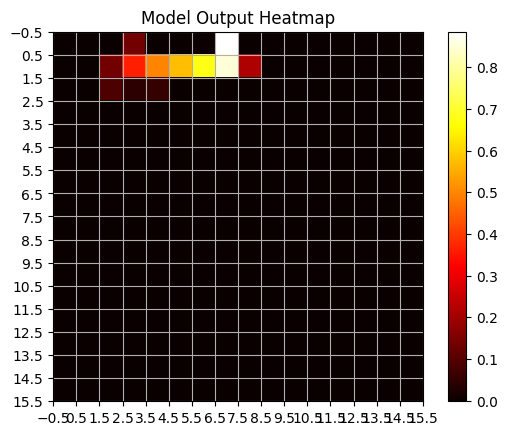

In [78]:
MODEL_RUN = 8
ind = 28

context = X_test_aug[ind:ind+1].to(DEVICE)                  
context_batch = context.repeat(MODEL_RUN, 1, 1, 1)    

samples = generate_flow_heatmap(trained_model, context_batch, inference_steps=20, cfg_scale=1.0, device=DEVICE)
averaged = samples.mean(dim=0, keepdim=True)       

plot_output_tensor(averaged)

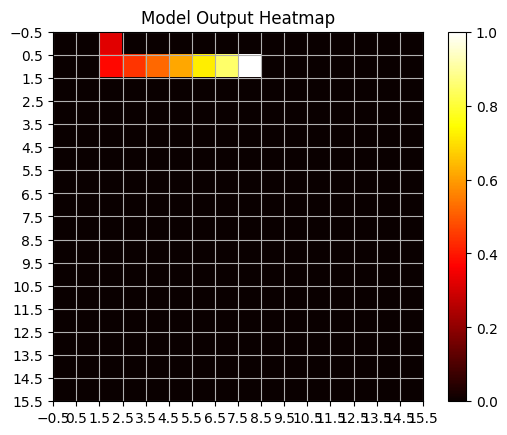

In [79]:
plot_output_tensor(y_test_aug[ind])

In [35]:
def get_accuracy_on_test_set(model, X_test, y_test, device=DEVICE):
    model.eval()
    total_samples = X_test.size(0)
    correct_predictions = 0

    accuracy_dict = {}
    with torch.no_grad():
        for i in tqdm(range(total_samples)):
            context = X_test[i:i+1].to(device)
            unseen_count = context[0][2].sum().item()
            true_heatmap = y_test[i:i+1].to(device)

            # Generate predicted heatmap
            MODEL_RUN = 8
            context_batch = context.repeat(MODEL_RUN, 1, 1, 1)    

            predicted_heatmap = generate_flow_heatmap(model, context_batch, inference_steps=20, cfg_scale=1.0, device=device).mean(dim=0, keepdim=True) 

            # curr_pos = context[0][1].argmax(axis=None)
            gt_brightest_pos = true_heatmap[0][0].argmax(axis=None)
            pred_brightest_pos = predicted_heatmap[0][0].argmax(axis=None)

            correct_predictions += (gt_brightest_pos == pred_brightest_pos).item()
            key = unseen_count // 10
            if key not in accuracy_dict:
                accuracy_dict[key] = {"correct": 0, "total": 0}
            accuracy_dict[key]["correct"] += (gt_brightest_pos == pred_brightest_pos).item()
            accuracy_dict[key]["total"] += 1

    accuracy = correct_predictions / total_samples
    return accuracy, accuracy_dict

acc, acc_dict = get_accuracy_on_test_set(trained_model, X_test[:5000], y_test[:5000], device=DEVICE)
print(f"Overall Accuracy on Test Set: {acc:.4f}")


100%|██████████| 5000/5000 [06:52<00:00, 12.13it/s]

Overall Accuracy on Test Set: 0.8060


In [38]:
for k in sorted(acc_dict):
    correct = acc_dict[k]["correct"]
    total = acc_dict[k]["total"]
    accuracy = correct / total if total > 0 else 0
    print(f"Unseen Cells: {k*10}-{(k+1)*10 - 1}, Accuracy: {accuracy:.4f} ({correct}/{total})")

Unseen Cells: 10.0-19.0, Accuracy: 0.8750 (63/72)
Unseen Cells: 20.0-29.0, Accuracy: 0.8393 (94/112)
Unseen Cells: 30.0-39.0, Accuracy: 0.8333 (155/186)
Unseen Cells: 40.0-49.0, Accuracy: 0.8446 (250/296)
Unseen Cells: 50.0-59.0, Accuracy: 0.7938 (231/291)
Unseen Cells: 60.0-69.0, Accuracy: 0.8193 (263/321)
Unseen Cells: 70.0-79.0, Accuracy: 0.8179 (274/335)
Unseen Cells: 80.0-89.0, Accuracy: 0.8237 (285/346)
Unseen Cells: 90.0-99.0, Accuracy: 0.8081 (240/297)
Unseen Cells: 100.0-109.0, Accuracy: 0.7909 (227/287)
Unseen Cells: 110.0-119.0, Accuracy: 0.8289 (252/304)
Unseen Cells: 120.0-129.0, Accuracy: 0.8053 (182/226)
Unseen Cells: 130.0-139.0, Accuracy: 0.8395 (204/243)
Unseen Cells: 140.0-149.0, Accuracy: 0.8216 (175/213)
Unseen Cells: 150.0-159.0, Accuracy: 0.8372 (180/215)
Unseen Cells: 160.0-169.0, Accuracy: 0.8270 (153/185)
Unseen Cells: 170.0-179.0, Accuracy: 0.8626 (157/182)
Unseen Cells: 180.0-189.0, Accuracy: 0.7558 (130/172)
Unseen Cells: 190.0-199.0, Accuracy: 0.8063 (154/

In [14]:
## Testing

## Testing

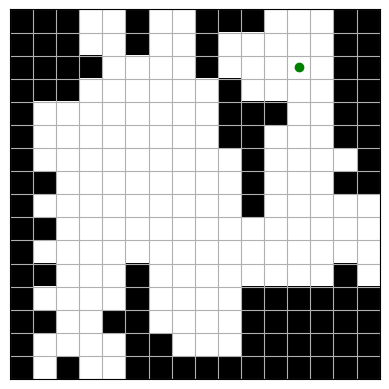

In [4]:
gen = WRPDataGenerator(16, 16)
# grid, start = gen.generate_simple_polygon_grid()
grid, start = gen.generate_simple_polygon_grid()


# start = (0, 0)  # Starting at the top-left corner
plot_grid(grid, start)  # Plot the grid from the first channel of the input

Success! Entire polygon explored in 73 steps.
Success! Entire grid explored optimally in 83 steps.
Loop detected at step 54 and pos (10, 4)! Triggering A* Escape.
New fog revealed! Breaking escape to replan.
Escape successful! New position: (13, 3). Continuing exploration.
Few frontiers (1) left at step 57 and pos (15, 3). Triggering A* Escape.
New fog revealed! Breaking escape to replan.
Escape successful! New position: (14, 1). Continuing exploration.
Success! Entire grid explored optimally in 58 steps.
Success! Entire polygon explored in 66 steps.


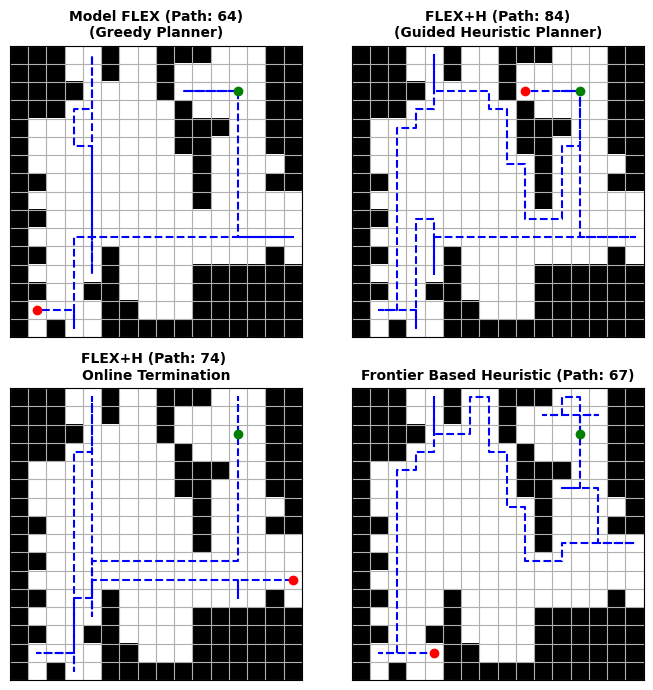

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))



# Algorithm 2: 
path_astar1 = receding_horizon_astar_online(trained_model, grid, start, los_type=LOS, vision_radius=VISION_RADIUS, device=DEVICE)
plt.sca(axes[1, 0])
plot_path(grid, path_astar1)
axes[1, 0].set_title(f'FLEX+H (Path: {len(path_astar1)}) \nOnline Termination', fontsize=10, fontweight='bold')

# Algorithm 3:
path_astar2 = receding_horizon_astar_online(trained_model, grid, start, los_type=LOS, vision_radius=VISION_RADIUS, device=DEVICE, stop_at_offline_compare=True)
plt.sca(axes[0, 1])
plot_path(grid, path_astar2)
axes[0, 1].set_title(f'FLEX+H (Path: {len(path_astar2)})\n(Guided Heuristic Planner)', fontsize=10, fontweight='bold')

# Algorithm 1: Greedy Online
path_greedy, data_ = pred_path_greedy_online_flow(trained_model, grid, start, los_type=LOS, vision_radius=VISION_RADIUS, device=DEVICE, stop_at_offline_compare=True)
plt.sca(axes[0, 0])
plot_path(grid, path_greedy)
axes[0, 0].set_title(f'Model FLEX (Path: {len(path_greedy)})\n(Greedy Planner)', fontsize=10, fontweight='bold')

# Algorithm 4: HIPPS
path_hipps = neasrest_frontier_algorithm(grid, start, los_type=LOS, vision_radius=VISION_RADIUS
                                         )
plt.sca(axes[1, 1])
plot_path(grid, path_hipps)
axes[1, 1].set_title(f'Frontier Based Heuristic (Path: {len(path_hipps)})', fontsize=10, fontweight='bold')



plt.tight_layout()
plt.show()

Optimized Path Length: 28
Lower Bound:  33.09090909090909


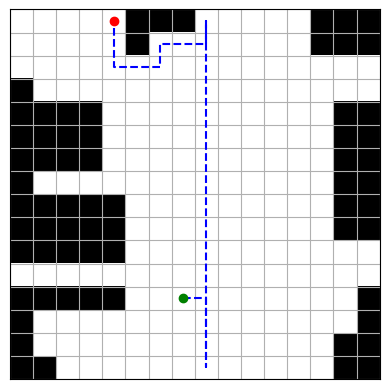

In [82]:
solver_opt = WRPSolverTSPJF(grid, start, los_type=LOS, vision_radius=VISION_RADIUS)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)
print("Optimized Path Length:", len(path_opt))
lower_bound = len(path_opt) * 13/11
print("Lower Bound: ", lower_bound)
plot_path(grid, path_opt, start)

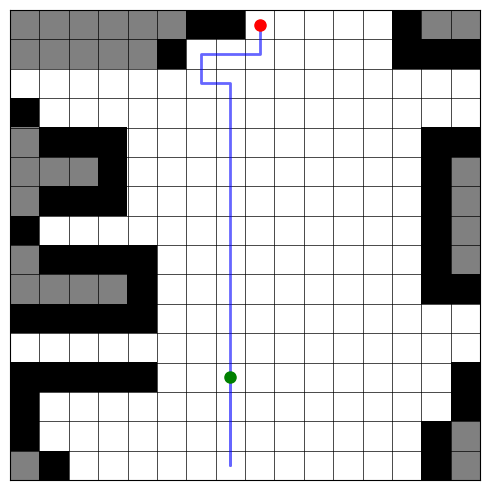

<Axes: >

In [83]:
plot_visibility2(grid, path_greedy[:22], los_type=LOS, vision_radius=VISION_RADIUS, grazing_walls=True)

In [236]:
import matplotlib
matplotlib.use("Agg")          # off-screen backend, no windows pop up
import imageio.v2 as imageio

def make_path_gif(grid, path, out="exploration.gif", fps=4,
                  los_type=LOS, vision_radius=VISION_RADIUS):
    frames = []
    for step in range(1, len(path) + 1):       # step 1 .. full path
        fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
        plot_visibility2(grid, path[:step], los_type=los_type,
                         vision_radius=vision_radius, grazing_walls=True, ax=ax)
        ax.set_title(f"Step {step}/{len(path)}")
        fig.canvas.draw()
        # grab the rendered RGBA buffer as an array
        frame = np.asarray(fig.canvas.buffer_rgba())
        frames.append(frame)
        plt.close(fig)                          # free memory — important for long paths
    imageio.mimsave(out, frames, fps=fps, loop=0)   # loop=0 = loop forever
    print(f"Saved {out} with {len(frames)} frames")

make_path_gif(grid, path_greedy)
%matplotlib inline
plt.ion()              # restore default backend for interactive plotting

Saved exploration.gif with 54 frames


## Evaluation

In [84]:
from data_generator import _solve_grid
def evaluate_model_on_random_grids(model, polygon_type = "simple_polygon", user_neural_search=True, num_samples=5, precomputed_gt=None, stop_at_offline_compare=False):
     model.eval()
     grid_size = (16, 16)
     gt_path_lengths = []
     pred_path_lengths = []
     pred_path_lengths_search = []
     pred_path_lengths_hipps = []
     # pred_path_lengths_visibility = []
     if precomputed_gt is not None:
          print("Using precomputed ground truth data for evaluation.")
          num_samples = min(num_samples, len(precomputed_gt["grid"]))
          
     print(f"Evaluating on {num_samples} samples")

     for i in tqdm(range(num_samples)):

          if precomputed_gt is None:
               gen = WRPDataGenerator(*grid_size)
               grid, start = None, None
               if polygon_type == "holes":
                    grid, start = gen.generate_valid_grid(density=5)
               elif polygon_type == "simple_polygon":
                    grid, start = gen.generate_simple_polygon_grid()
               # grid, start = gen.generate_valid_grid(density=0.2)
               # grid, start = gen.generate_simple_polygon_grid(density=0.2)

               path_opt = 257
               try:
                    path_opt, _ = run_with_timeout(_solve_grid, args=(grid, start, LOS, VISION_RADIUS), timeout=300)  # 5 minute timeout per sample
               except TimeoutError:
                    print(f"Skipping: Sample {i}: Optimization timed out. Skipping this sample.")
                    continue
          
          else:
               grid, start, path_opt = precomputed_gt["grid"][i].astype(np.int8), tuple(precomputed_gt["start"][i].astype(int)), precomputed_gt["path_opt"][i].astype(np.int8)

          path_pred_line, _ = pred_path_greedy_online_flow(model, grid, start, max_steps=256, verbose=False, los_type=LOS, vision_radius=VISION_RADIUS, stop_at_offline_compare=stop_at_offline_compare, device=DEVICE)
          if (user_neural_search):
               path_pred_line_search = receding_horizon_astar_online(model, grid, start, verbose=False ,los_type=LOS, vision_radius=VISION_RADIUS, stop_at_offline_compare=stop_at_offline_compare, device=DEVICE)
          hipps_pred_line = neasrest_frontier_algorithm(grid, start, verbose=False, los_type=LOS, vision_radius=VISION_RADIUS, stop_at_offline_compare=stop_at_offline_compare)
          

          if (len(path_opt) > len(path_pred_line) or len(path_opt) > len(hipps_pred_line)):
               print(f"DISCREPANCY Sample {i}: Predicted: {len(path_pred_line)}, Optimal: {len(path_opt)}")
          else:
               gt_path_lengths.append(len(path_opt))
               pred_path_lengths.append(len(path_pred_line))
               pred_path_lengths_hipps.append(len(hipps_pred_line))
               
               if user_neural_search: 
                    pred_path_lengths_search.append(len(path_pred_line_search))

     rmse = np.sqrt(np.mean([(gt - pred) ** 2 for gt, pred in zip(gt_path_lengths, pred_path_lengths)]))
     print(f"\nAverage Ground Truth Path Length: {np.mean(gt_path_lengths):.2f}")
     print(f"Average Predicted Path Length: {np.mean(pred_path_lengths):.2f}")
     print(f"Root Mean Squared Error in Path Lengths: {rmse:.2f}") 

     print("Ground Truth Path Length:  ", gt_path_lengths)
     print("Model Predict Path Length: ", pred_path_lengths)
     print("Nearest Frontier Predict Path Length: ", pred_path_lengths_hipps)
     
     # print("Visibility Predict Path Length: ", pred_path_lengths_visibility)
     if user_neural_search:
          print("Neural Search Path Length: ", pred_path_lengths_search)
          return np.array(gt_path_lengths), np.array(pred_path_lengths), np.array(pred_path_lengths_search), np.array(pred_path_lengths_hipps)
     else:
          return np.array(gt_path_lengths), np.array(pred_path_lengths), None , np.array(pred_path_lengths_hipps)

In [85]:
gt_path_lengths1, pred_path_lengths1, pred_path_lengths_search1, pred_path_lengths_hipps1 = evaluate_model_on_random_grids(trained_model, num_samples=100, precomputed_gt=None, stop_at_offline_compare=True)


Evaluating on 100 samples


100%|██████████| 100/100 [08:42<00:00,  5.22s/it]


Average Ground Truth Path Length: 34.64
Average Predicted Path Length: 45.15
Root Mean Squared Error in Path Lengths: 14.75
Ground Truth Path Length:   [39, 32, 43, 31, 58, 30, 27, 21, 47, 34, 59, 34, 29, 32, 38, 33, 24, 65, 33, 23, 35, 42, 24, 32, 30, 38, 35, 42, 30, 46, 32, 28, 19, 40, 26, 31, 27, 31, 39, 29, 47, 64, 36, 31, 29, 23, 26, 20, 31, 32, 41, 40, 36, 67, 44, 26, 59, 32, 38, 30, 41, 33, 37, 44, 24, 28, 31, 43, 21, 22, 43, 47, 17, 25, 32, 24, 47, 24, 35, 42, 29, 16, 41, 37, 46, 30, 31, 42, 33, 35, 38, 35, 39, 42, 24, 25, 23, 38, 35, 25]
Model Predict Path Length:  [41, 33, 62, 37, 74, 39, 51, 21, 65, 43, 60, 43, 56, 44, 69, 52, 43, 87, 37, 39, 41, 48, 31, 33, 46, 50, 36, 48, 46, 84, 36, 28, 23, 50, 26, 42, 27, 70, 52, 55, 52, 108, 40, 31, 35, 24, 32, 34, 47, 41, 47, 52, 61, 89, 55, 29, 75, 41, 38, 30, 45, 34, 69, 47, 29, 28, 34, 52, 21, 22, 43, 49, 35, 25, 40, 24, 66, 43, 41, 68, 47, 16, 50, 79, 56, 34, 33, 43, 33, 40, 57, 45, 53, 42, 25, 36, 33, 40, 63, 46]
Nearest Frontier

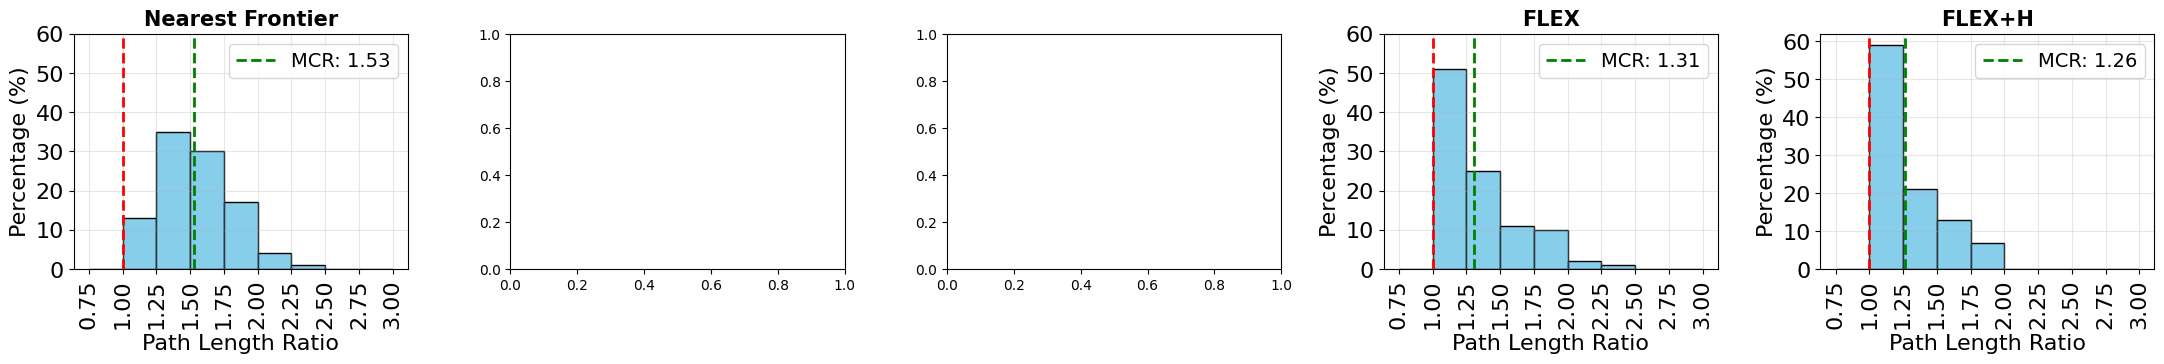

In [86]:
path_len_diff_model1 = pred_path_lengths1 - gt_path_lengths1
path_len_ratio_model1 = pred_path_lengths1 / gt_path_lengths1

path_len_diff_search1 = pred_path_lengths_search1 - gt_path_lengths1
path_len_ratio_search1 = pred_path_lengths_search1 / gt_path_lengths1

path_len_diff_hipps1 = pred_path_lengths_hipps1 - gt_path_lengths1
path_len_ratio_hipps1 = pred_path_lengths_hipps1 / gt_path_lengths1


# Font sizes
TITLE_SIZE = 15
LABEL_SIZE = 16
TICK_SIZE = 16
LEGEND_SIZE = 14

# Plot settings
step = 0.25


fig, axes = plt.subplots(1, 5, figsize=(22, 4))

# Plot 1
plot_percentage_hist(axes[0], path_len_ratio_hipps1, step, "Nearest Frontier", title_size=TITLE_SIZE, label_size=LABEL_SIZE, tick_size=TICK_SIZE, legend_size=LEGEND_SIZE)


# Plot 2
plot_percentage_hist(axes[3], path_len_ratio_model1, step, "FLEX", title_size=TITLE_SIZE, label_size=LABEL_SIZE, tick_size=TICK_SIZE, legend_size=LEGEND_SIZE)


# Plot 3
plot_percentage_hist(axes[4], path_len_ratio_search1, step, "FLEX+H", title_size=TITLE_SIZE, label_size=LABEL_SIZE, tick_size=TICK_SIZE, legend_size=LEGEND_SIZE)




plt.tight_layout(pad=2.0)
plt.show()

## ## Learning on Polygon examples

In [109]:
from io import BytesIO
import joblib
import zlib

with open("data/Minimum_Feature_25_Dataset_Uniform_Continuous_SDF_Processed_Dataset/batch_2.pkl", "rb") as f:
    d0 = joblib.load(BytesIO(zlib.decompress(f.read())))
# (d0)
len(d0)

128

In [88]:
def create_polygon_batch(folder_path):
    polygons_pkl_files = os.listdir(folder_path)
    polygon_batch = {}
    for i in polygons_pkl_files:
        with open(os.path.join(folder_path, i), "rb") as f:
            polygon_batch[i] = joblib.load(BytesIO(f.read()))
    return polygon_batch

test_batch1 = create_polygon_batch("data/Specific_Type_Polygon_Test_25_Processed")
test_batch2 = create_polygon_batch("data/Minimum_Feature_25_Dataset_Test_New_Processed")


Randomly selected polygon index: 85 || Polygon key: 25_3_coords.pkl


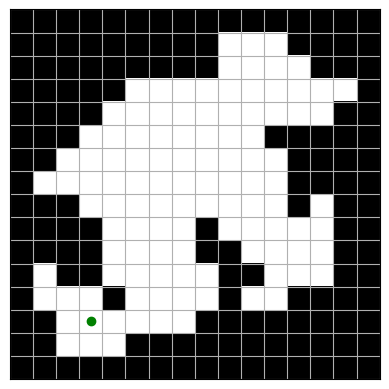

In [130]:
d0 = test_batch2
polygon_index = np.random.randint(0, len(d0) - 1)
k = list(d0.keys())[polygon_index]
print(f"Randomly selected polygon index: {polygon_index} || Polygon key: {k}")
polygon = d0[k]["level_2_polygon"]

grid_16, extent_16, fill_16 = polygon_to_obstacle_grid(polygon, grid_shape=(16, 16), samples_per_cell=8)
# start from anywhere at random where there is no obstacle
free_cells = np.argwhere(grid_16 == 0)
start_index = np.random.choice(len(free_cells))
start_16 = tuple(free_cells[start_index])
plot_grid(grid_16, start_16)

Success! Entire polygon explored in 60 steps.
Success! Entire grid explored optimally in 49 steps.
Loop detected at step 18 and pos (np.int64(13), np.int64(3))! Triggering A* Escape.
New fog revealed! Breaking escape to replan.
Escape successful! New position: (np.int64(11), np.int64(5)). Continuing exploration.
Few frontiers (1) left at step 45 and pos (np.int64(3), np.int64(13)). Triggering A* Escape.
New fog revealed! Breaking escape to replan.
Escape successful! New position: (np.int64(12), np.int64(11)). Continuing exploration.
Success! Entire grid explored optimally in 46 steps.
Success! Entire polygon explored in 41 steps.


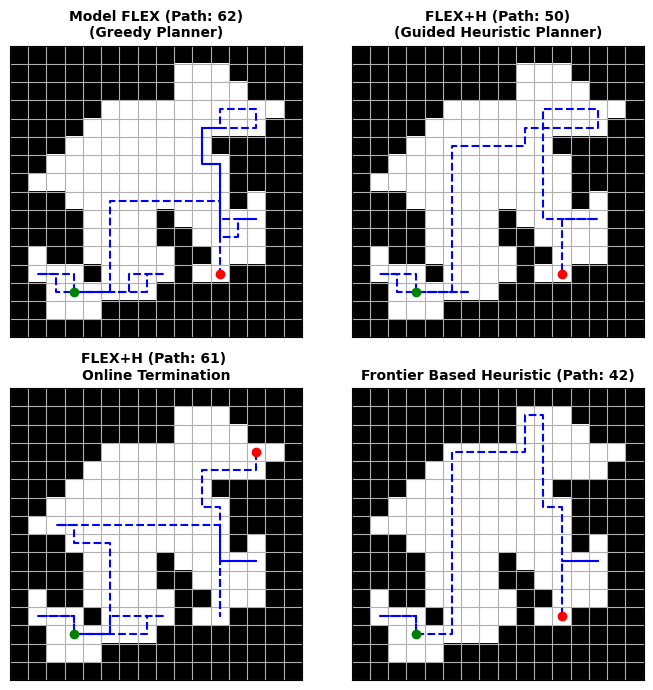

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))



# Algorithm 2: 
path_astar1 = receding_horizon_astar_online(trained_model, grid_16, start_16, los_type=LOS, vision_radius=VISION_RADIUS, device=DEVICE)
plt.sca(axes[1, 0])
plot_path(grid_16, path_astar1)
axes[1, 0].set_title(f'FLEX+H (Path: {len(path_astar1)}) \nOnline Termination', fontsize=10, fontweight='bold')

# Algorithm 3:
path_astar2 = receding_horizon_astar_online(trained_model, grid_16, start_16, los_type=LOS, vision_radius=VISION_RADIUS, device=DEVICE, stop_at_offline_compare=True)
plt.sca(axes[0, 1])
plot_path(grid_16, path_astar2)
axes[0, 1].set_title(f'FLEX+H (Path: {len(path_astar2)})\n(Guided Heuristic Planner)', fontsize=10, fontweight='bold')

# Algorithm 1: Greedy Online
path_greedy, data_ = pred_path_greedy_online_flow(trained_model, grid_16, start_16, los_type=LOS, vision_radius=VISION_RADIUS, device=DEVICE, stop_at_offline_compare=True)
plt.sca(axes[0, 0])
plot_path(grid_16, path_greedy)
axes[0, 0].set_title(f'Model FLEX (Path: {len(path_greedy)})\n(Greedy Planner)', fontsize=10, fontweight='bold')

# Algorithm 4: HIPPS
path_hipps = neasrest_frontier_algorithm(grid_16, start_16, los_type=LOS, vision_radius=VISION_RADIUS)
plt.sca(axes[1, 1])
plot_path(grid_16, path_hipps)
axes[1, 1].set_title(f'Frontier Based Heuristic (Path: {len(path_hipps)})', fontsize=10, fontweight='bold')



plt.tight_layout()
plt.show()

Optimized Path Length: 20


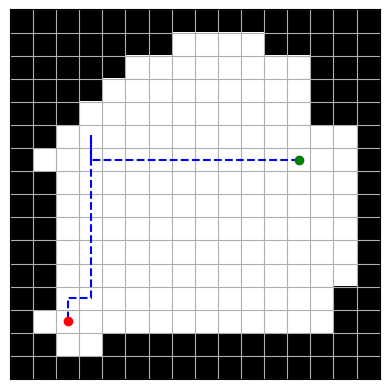

In [16]:
solver_opt = WRPSolverTSPJF(grid_16, start_16)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)
print("Optimized Path Length:", len(path_opt))
plot_path(grid_16, path_opt, start_16)

In [94]:
from data_generator import _solve_grid

def evaluate_model_on_visdiff_data(model, vis_diff_data_batch, user_neural_search=True, num_samples=5, stop_at_offline_compare=False):
     model.eval()
     gt_path_lengths = []
     pred_path_lengths = []
     pred_path_lengths_search = []
     pred_path_lengths_hipps = []
     # pred_path_lengths_visibility = []
     skipped = 0

     if (num_samples > len(vis_diff_data_batch) or num_samples <= 0):
          print(f"Requested num_samples ({num_samples}) exceeds available data ({len(vis_diff_data_batch)}). Evaluating on all available samples.")
          num_samples = len(vis_diff_data_batch)

     for k in tqdm(list(vis_diff_data_batch.keys())[:num_samples]):
          polygon = vis_diff_data_batch[k]["level_2_polygon"]
          grid, extent_16, fill_16 = polygon_to_obstacle_grid(polygon, grid_shape=(16, 16), samples_per_cell=8)

          # IMPORTANT: choose start from the current grid (not a stale global grid_16)
          free_cells = np.argwhere(grid == 0)
          if len(free_cells) == 0:
               continue

          start_index = np.random.choice(len(free_cells))
          start = tuple(map(int, free_cells[start_index]))

          path_opt = 257
          try:
               path_opt, _ = run_with_timeout(_solve_grid, args=(grid, start), timeout=600)  # 10 minute timeout per sample
          except TimeoutError:
               print(f"Skipping: Sample {k}: Optimization timed out. Skipping this sample.")
               skipped += 1
               continue

          path_pred_line, _ = pred_path_greedy_online_flow(model, grid, start, max_steps=256, verbose=False, los_type=LOS, vision_radius=VISION_RADIUS, stop_at_offline_compare=stop_at_offline_compare, device=DEVICE)
          if (user_neural_search):
               path_pred_line_search = receding_horizon_astar_online(model, grid, start, verbose=False, los_type=LOS, vision_radius=VISION_RADIUS, stop_at_offline_compare=stop_at_offline_compare, device=DEVICE)
          hipps_pred_line = neasrest_frontier_algorithm(grid, start, verbose=False, los_type=LOS, vision_radius=VISION_RADIUS, stop_at_offline_compare=stop_at_offline_compare)
          

          gt_path_lengths.append(len(path_opt))
          pred_path_lengths.append(len(path_pred_line))
          pred_path_lengths_hipps.append(len(hipps_pred_line))
          
          if user_neural_search: 
               pred_path_lengths_search.append(len(path_pred_line_search))

     rmse = np.sqrt(np.mean([(gt - pred) ** 2 for gt, pred in zip(gt_path_lengths, pred_path_lengths)]))
     print(f"\nAverage Ground Truth Path Length: {np.mean(gt_path_lengths):.2f}")
     print(f"Average Predicted Path Length: {np.mean(pred_path_lengths):.2f}")
     print(f"Root Mean Squared Error in Path Lengths: {rmse:.2f}") 

     print("Ground Truth Path Length:  ", gt_path_lengths)
     print("Model Predict Path Length: ", pred_path_lengths)
     print("Nearest Frontier Predict Path Length: ", pred_path_lengths_hipps)

     if user_neural_search:
          print("Neural Search Path Length: ", pred_path_lengths_search)
          return np.array(gt_path_lengths), np.array(pred_path_lengths), np.array(pred_path_lengths_search), np.array(pred_path_lengths_hipps)
     return np.array(gt_path_lengths), np.array(pred_path_lengths), None , np.array(pred_path_lengths_hipps)

In [95]:
gt_path_lengths, pred_path_lengths_model, pred_path_lengths_search, pred_path_lengths_hipps = evaluate_model_on_visdiff_data(trained_model, test_batch2, user_neural_search=True, num_samples=-1, stop_at_offline_compare=True)

Requested num_samples (-1) exceeds available data (300). Evaluating on all available samples.


100%|██████████| 300/300 [21:43<00:00,  4.35s/it]


Average Ground Truth Path Length: 36.94
Average Predicted Path Length: 48.49
Root Mean Squared Error in Path Lengths: 15.90
Ground Truth Path Length:   [51, 42, 41, 38, 37, 19, 28, 48, 16, 36, 22, 45, 50, 42, 43, 14, 44, 57, 25, 36, 43, 18, 41, 39, 39, 39, 14, 28, 37, 26, 18, 23, 33, 74, 34, 32, 44, 50, 38, 46, 49, 20, 52, 31, 46, 58, 24, 47, 36, 30, 39, 53, 44, 19, 47, 20, 21, 20, 20, 54, 38, 32, 47, 47, 42, 35, 42, 21, 58, 54, 35, 19, 30, 45, 39, 41, 44, 48, 46, 43, 31, 39, 30, 15, 52, 49, 39, 54, 36, 45, 24, 20, 32, 25, 36, 48, 39, 46, 20, 22, 28, 38, 51, 38, 35, 56, 44, 14, 48, 22, 52, 30, 35, 37, 62, 46, 47, 63, 37, 47, 27, 16, 24, 48, 50, 49, 40, 43, 18, 19, 44, 43, 46, 43, 45, 37, 16, 38, 42, 44, 37, 17, 18, 14, 34, 34, 57, 49, 36, 52, 49, 20, 48, 57, 42, 23, 44, 29, 44, 49, 21, 29, 32, 14, 20, 37, 40, 36, 51, 40, 45, 40, 55, 40, 61, 19, 14, 44, 41, 17, 41, 42, 42, 16, 37, 44, 27, 46, 15, 19, 14, 38, 27, 30, 17, 44, 53, 49, 48, 38, 35, 56, 49, 23, 57, 34, 62, 39, 38, 27, 44, 47

In [96]:
print("Mean GT PAth Length: ", np.mean(gt_path_lengths), f" std = {np.std(gt_path_lengths)}")
print("Mean Frontier Search Path Length: ", np.mean(pred_path_lengths_hipps), f" std = {np.std(pred_path_lengths_hipps)}")

print("Mean Model Path Length: ", np.mean(pred_path_lengths_model), f" std = {np.std(pred_path_lengths_model)}")
print("Mean Search Path Length: ", np.mean(pred_path_lengths_search), f" std = {np.std(pred_path_lengths_search)}")





Mean GT PAth Length:  36.943333333333335  std = 12.346664416846448
Mean Frontier Search Path Length:  50.64  std = 15.663664960666134
Mean Model Path Length:  48.49  std = 18.973224115403617
Mean Search Path Length:  47.10333333333333  std = 16.663912772482007


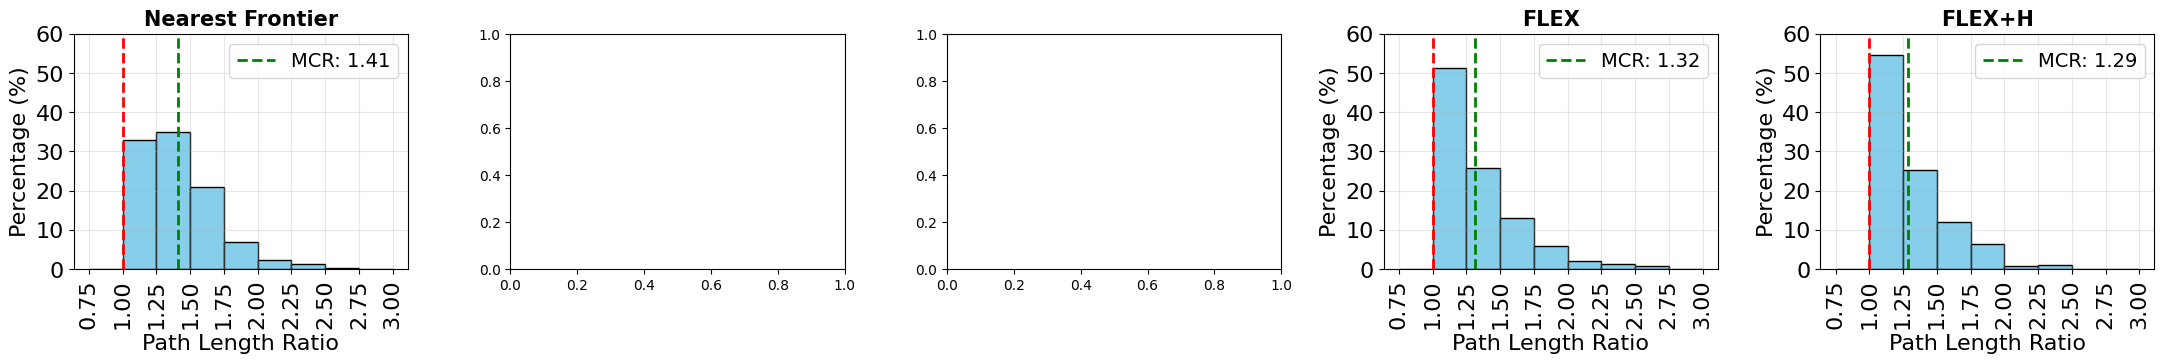

In [107]:
path_len_diff_model = pred_path_lengths_model - gt_path_lengths
path_len_ratio_model = pred_path_lengths_model / gt_path_lengths

path_len_diff_search = pred_path_lengths_search - gt_path_lengths
path_len_ratio_search = pred_path_lengths_search / gt_path_lengths

path_len_diff_hipps = pred_path_lengths_hipps - gt_path_lengths
path_len_ratio_hipps = pred_path_lengths_hipps / gt_path_lengths


# Font sizes
TITLE_SIZE = 15
LABEL_SIZE = 16
TICK_SIZE = 16
LEGEND_SIZE = 14

# Plot settings
step = 0.25


fig, axes = plt.subplots(1, 5, figsize=(22, 4))

# Plot 1
plot_percentage_hist(axes[0], path_len_ratio_hipps, step, "Nearest Frontier", title_size=TITLE_SIZE, label_size=LABEL_SIZE, tick_size=TICK_SIZE, legend_size=LEGEND_SIZE)


# Plot 2
plot_percentage_hist(axes[3], path_len_ratio_model, step, "FLEX", title_size=TITLE_SIZE, label_size=LABEL_SIZE, tick_size=TICK_SIZE, legend_size=LEGEND_SIZE)


# Plot 3
plot_percentage_hist(axes[4], path_len_ratio_search, step, "FLEX+H", title_size=TITLE_SIZE, label_size=LABEL_SIZE, tick_size=TICK_SIZE, legend_size=LEGEND_SIZE)



# Plot 4
# plot_percentage_hist(axes[3], path_len_ratio_hipps, "ARiADNE")

plt.tight_layout(pad=2.0)
plt.show()

In [26]:
#save results to npy
results_dict = {
    "gt_path_lengths": gt_path_lengths,
    "pred_path_lengths": pred_path_lengths_model,
    "pred_path_lengths_search": pred_path_lengths_search,
    "pred_path_lengths_hipps": pred_path_lengths_hipps,
}

np.save("evaluation_results/evaluation_results_visdiff_test.npy", results_dict)

In [ ]:
save_evaluation_results(pred_path_lengths_model, pred_path_lengths_model, pred_path_lengths_search, pred_path_lengths_hipps, filename="data/vis_diff_evaluation_results_grazing_simple_polygon.npz")